# Regresión polinómica

En este notebook veremos cómo funciona la **regresión polinómica**.

La idea clave es:

- **No cambiamos el algoritmo de regresión lineal**
- **Cambiamos la representación de la entrada**

Es decir, transformamos la variable original en nuevas variables como:

$[
x, x^2, x^3,...
]$

y después aplicamos una regresión lineal sobre esas nuevas variables.


## 1. Importaciones


In [1]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split


## 2. Generación de datos

Creamos un conjunto de datos con una relación **no lineal**.


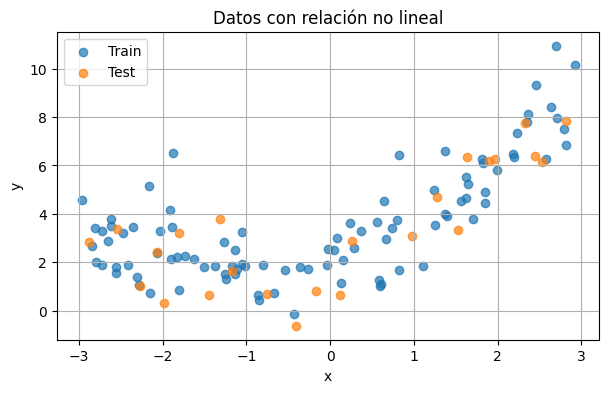

In [2]:
np.random.seed(42)

X = 6 * np.random.rand(120, 1) - 3
y = 0.5 * X[:, 0]**2 + X[:, 0] + 2 + np.random.randn(120) * 1.2

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

plt.figure(figsize=(7, 4))
plt.scatter(X_train, y_train, alpha=0.7, label='Train')
plt.scatter(X_test, y_test, alpha=0.7, label='Test')
plt.xlabel('x')
plt.ylabel('y')
plt.title('Datos con relación no lineal')
plt.legend()
plt.grid(True)
plt.show()


## 3. Comparación inicial: regresión lineal vs regresión polinómica

Primero ajustamos una regresión lineal simple para ver que una recta no modela bien estos datos.


In [3]:
modelo_lineal = LinearRegression()
modelo_lineal.fit(X_train, y_train)

y_pred_lineal = modelo_lineal.predict(X_test)
mse_lineal = mean_squared_error(y_test, y_pred_lineal)

print(f'MSE regresión lineal: {mse_lineal:.4f}')


MSE regresión lineal: 3.0195


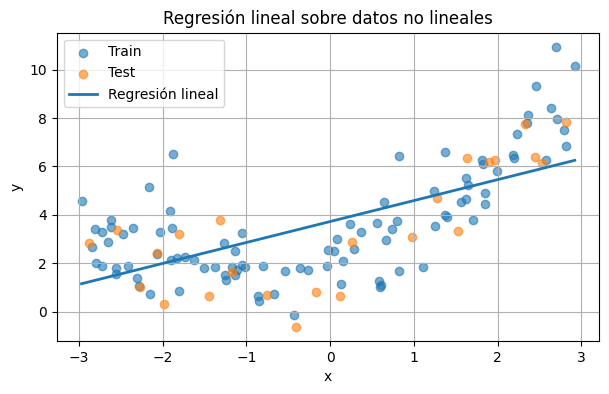

In [4]:
X_plot = np.linspace(X.min(), X.max(), 300).reshape(-1, 1)
y_plot_lineal = modelo_lineal.predict(X_plot)

plt.figure(figsize=(7, 4))
plt.scatter(X_train, y_train, alpha=0.6, label='Train')
plt.scatter(X_test, y_test, alpha=0.6, label='Test')
plt.plot(X_plot, y_plot_lineal, linewidth=2, label='Regresión lineal')
plt.xlabel('x')
plt.ylabel('y')
plt.title('Regresión lineal sobre datos no lineales')
plt.legend()
plt.grid(True)
plt.show()


## 4. Regresión polinómica de grado 2

Transformamos la variable original en variables polinómicas y luego aplicamos `LinearRegression()`.

Por ejemplo, para grado 2:

$
x \rightarrow [x, x^2]
$


In [5]:
poly2 = PolynomialFeatures(degree=2, include_bias=False) # le indicamos el grado y que no añada columna de 1s, el intercepto lo gestiona después el modelo -> Define la transformación
X_train_poly2 = poly2.fit_transform(X_train)             # ajusta y hace la transformación que corresponde en este caso [x, x^2] -> Aprende + transforma train
X_test_poly2 = poly2.transform(X_test)                   # aquí solo hace transformación, NO debe aprender del test -> Transforma test

modelo_poly2 = LinearRegression()
modelo_poly2.fit(X_train_poly2, y_train)

y_pred_poly2 = modelo_poly2.predict(X_test_poly2)
mse_poly2 = mean_squared_error(y_test, y_pred_poly2)

print(f'MSE regresión polinómica grado 2: {mse_poly2:.4f}')
print('Coeficientes:', modelo_poly2.coef_)
print('Intercepto:', modelo_poly2.intercept_)


MSE regresión polinómica grado 2: 1.4486
Coeficientes: [0.95372154 0.49124709]
Intercepto: 2.180240385821304


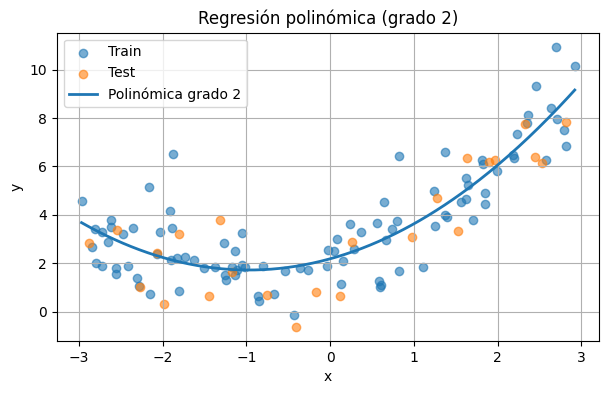

In [6]:
X_plot_poly2 = poly2.transform(X_plot)
y_plot_poly2 = modelo_poly2.predict(X_plot_poly2)

plt.figure(figsize=(7, 4))
plt.scatter(X_train, y_train, alpha=0.6, label='Train')
plt.scatter(X_test, y_test, alpha=0.6, label='Test')
plt.plot(X_plot, y_plot_poly2, linewidth=2, label='Polinómica grado 2')
plt.xlabel('x')
plt.ylabel('y')
plt.title('Regresión polinómica (grado 2)')
plt.legend()
plt.grid(True)
plt.show()


## 5. Comparación de varios grados

Ahora comparamos distintos grados para ver cómo cambia la flexibilidad del modelo.


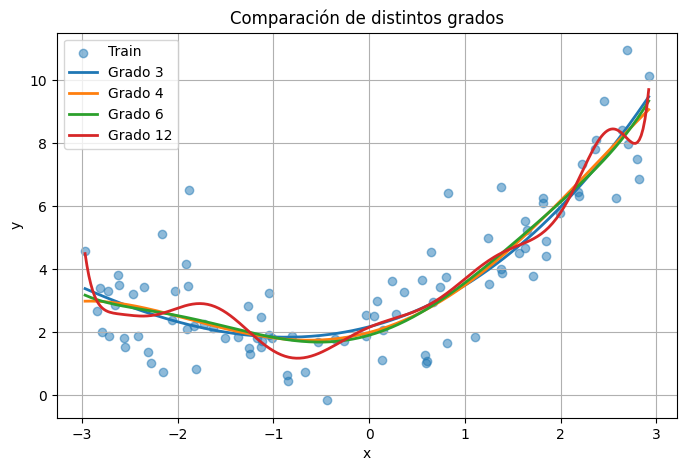

Grado 3 -> MSE en test: 1.5123
Grado 4 -> MSE en test: 1.4309
Grado 6 -> MSE en test: 1.3869
Grado 12 -> MSE en test: 1.6226


In [13]:
grados = [3, 4, 6, 12]
resultados = []

plt.figure(figsize=(8, 5))
plt.scatter(X_train, y_train, alpha=0.5, label='Train')

for grado in grados:
    poly = PolynomialFeatures(degree=grado, include_bias=False)
    X_train_poly = poly.fit_transform(X_train)
    X_test_poly = poly.transform(X_test)
    X_plot_poly = poly.transform(X_plot)

    modelo = LinearRegression()
    modelo.fit(X_train_poly, y_train)

    y_pred = modelo.predict(X_test_poly)
    mse = mean_squared_error(y_test, y_pred)
    resultados.append((grado, mse))

    y_plot = modelo.predict(X_plot_poly)
    plt.plot(X_plot, y_plot, linewidth=2, label=f'Grado {grado}')

plt.xlabel('x')
plt.ylabel('y')
plt.title('Comparación de distintos grados')
plt.legend()
plt.grid(True)
plt.show()

for grado, mse in resultados:
    print(f'Grado {grado} -> MSE en test: {mse:.4f}')


## 6. Idea importante

La regresión polinómica **sigue siendo una regresión lineal en los parámetros**.

Por ejemplo, un modelo de grado 2 tiene la forma:

$
y = w_0 + w_1 x + w_2 x^2
$

Aunque la curva no sea una recta, el modelo sigue siendo lineal respecto a los coeficientes `w`.

Por eso puede resolverse con la **solución analítica clásica** usando `LinearRegression()`.


## 7. Comparación final: lineal vs polinómica


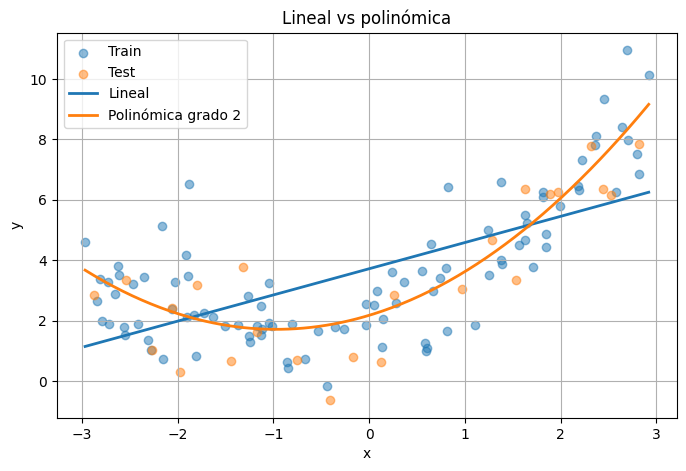

MSE lineal: 3.0195
MSE polinómica grado 2: 1.4486


In [8]:
plt.figure(figsize=(8, 5))
plt.scatter(X_train, y_train, alpha=0.5, label='Train')
plt.scatter(X_test, y_test, alpha=0.5, label='Test')
plt.plot(X_plot, y_plot_lineal, linewidth=2, label='Lineal')
plt.plot(X_plot, y_plot_poly2, linewidth=2, label='Polinómica grado 2')
plt.xlabel('x')
plt.ylabel('y')
plt.title('Lineal vs polinómica')
plt.legend()
plt.grid(True)
plt.show()

print(f'MSE lineal: {mse_lineal:.4f}')
print(f'MSE polinómica grado 2: {mse_poly2:.4f}')


## 8. Qué deben concluir

- La regresión polinómica permite modelar relaciones no lineales.
- No cambia el algoritmo base de entrenamiento.
- Lo que cambia es la **representación de la entrada**.
- Un grado demasiado bajo puede no capturar la relación.
- Un grado demasiado alto puede sobreajustar.


## 9. Ejercicios

1. Probar grados 3, 4, 6 y 12.
2. Aumentar el ruido y observar qué ocurre.
3. Reducir el número de muestras y comprobar si aparece sobreajuste antes.
4. Comparar siempre el error en train y en test.
5. Intentar explicar visualmente qué significa que el modelo sea más flexible.
